In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/titanic_cleaned.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,age_missing,family_size,is_alone,fare_per_person
0,False,3,male,22.0,1,0,7.2500,s,third,man,True,southampton,no,False,False,2,False,3.62500
1,True,1,female,38.0,1,0,71.2833,c,first,woman,False,cherbourg,yes,False,False,2,False,35.64165
2,True,3,female,26.0,0,0,7.9250,s,third,woman,False,southampton,yes,True,False,1,True,7.92500
3,True,1,female,35.0,1,0,53.1000,s,first,woman,False,southampton,yes,False,False,2,False,26.55000
4,False,3,male,35.0,0,0,8.0500,s,third,man,True,southampton,no,True,False,1,True,8.05000


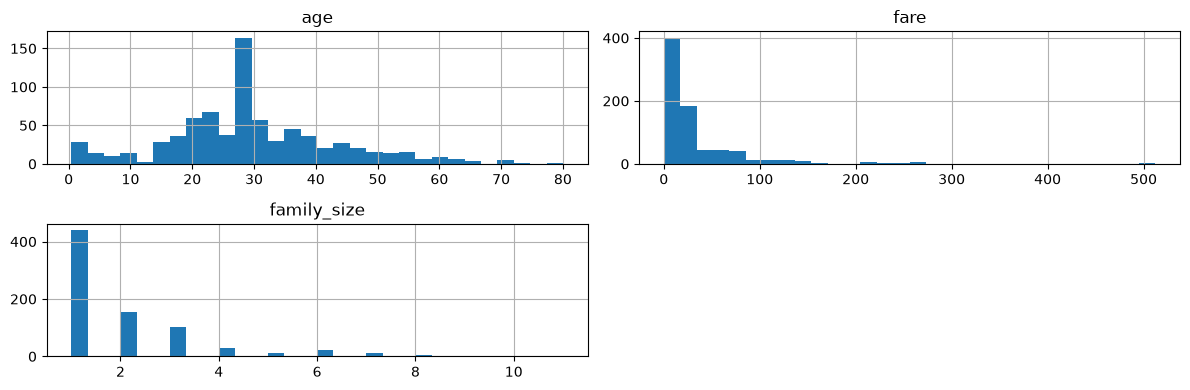

In [2]:
df[["age", "fare", "family_size"]].hist(bins=30, figsize=(12, 4))
plt.tight_layout()
plt.show()

In [3]:
df.groupby("sex")["survived"].mean()

sex
female    0.737931
male      0.217213
Name: survived, dtype: float64

In [4]:
df.groupby("pclass")["survived"].mean()

pclass
1    0.633333
2    0.506098
3    0.257426
Name: survived, dtype: float64

In [5]:
df.groupby(["sex", "pclass"])["survived"].mean()

sex     pclass
female  1         0.967033
        2         0.916667
        3         0.472441
male    1         0.378151
        2         0.184783
        3         0.158845
Name: survived, dtype: float64

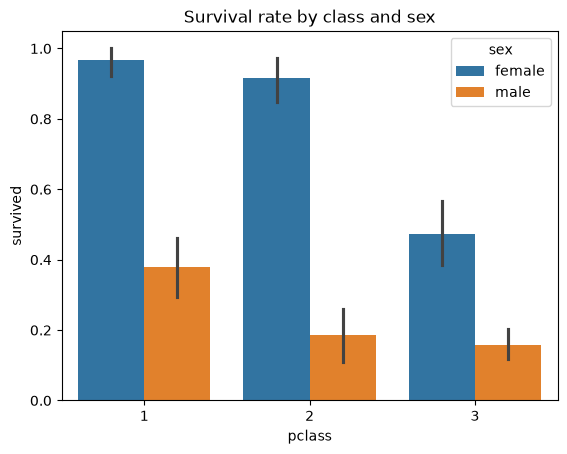

In [6]:
sns.barplot(data=df, x="pclass", y="survived", hue="sex")
plt.title("Survival rate by class and sex")
plt.show()

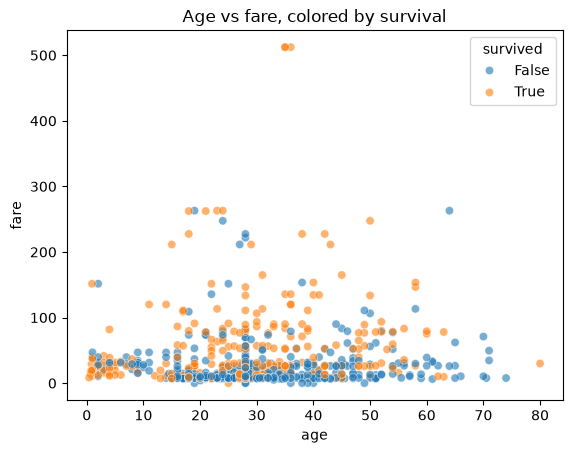

In [7]:
sns.scatterplot(data=df, x="age", y="fare", hue="survived", alpha=0.6)
plt.title("Age vs fare, colored by survival")
plt.show()

## Candidate Insights

1. **Sex was the single strongest predictor of survival.** Women survived at 
   73.8% overall vs 21.7% for men — a huge gap regardless of class.
   - *Follow-up question:* Was this driven by "women and children first" 
     lifeboat policy, or by where women vs men tended to be located on the ship?

2. **Class amplified the sex gap rather than replacing it.** First-class women 
   survived 96.7% of the time (91 passengers), while third-class men survived 
   only 15.9% of the time — the single worst group (277 passengers, the largest 
   group on the ship).
   - *Follow-up question:* Was third-class men's low survival due to cabin 
     location, lifeboat access order, or sheer numbers overwhelming available 
     lifeboats?

3. **Family size shows a possible sweet spot.** Most passengers traveled alone 
   (family_size = 1), with survival dropping off sharply for very large families.
   - *Follow-up question:* Did small families (2-4 people) survive at a higher 
     rate than solo travelers or large families? Worth a direct group-by to 
     confirm.

4. **Age vs fare shows no strong linear pattern**, but higher-fare passengers 
   (mostly 1st class) skew toward survival regardless of age — reinforcing 
   that class/fare mattered more than age alone.

**Note:** These are observed associations in this sample, not proven causes. 
The "women and children first" pattern is a well-known historical policy, but 
confirming *why* class mattered this much (physical ship layout vs social 
factors) would need further investigation beyond this dataset.

In [8]:
df.groupby(["pclass", "sex"])["survived"].agg(["mean", "count"])

mean  count
pclass sex                    
1      female  0.967033     91
       male    0.378151    119
2      female  0.916667     72
       male    0.184783     92
3      female  0.472441    127
       male    0.158845    277

In [9]:
df.groupby("family_size")["survived"].mean()

family_size
1     0.334091
2     0.551948
3     0.574257
4     0.714286
5     0.230769
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: survived, dtype: float64